# Final Continuous SBEED Experiments

This notebook inspects the continuous-control results for SBEED, mainly Pendulum-v1. It focuses on loading good configurations from the larger searches, evaluating the learned Gaussian policy, and visualizing training/evaluation behavior.

What to look for:
- how the continuous value, rho, and RFF Gaussian policy modules are assembled,
- deterministic evaluation of trained policies,
- comparison between training diagnostics and final policy returns.


Showing best results gotten after a big search in the pendulum problem of SBEED

In [1]:
%load_ext autoreload
%autoreload 2

import random
import sys
from pathlib import Path
from types import SimpleNamespace

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Continuous scripts use float32 modules.
torch.set_default_dtype(torch.float32)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def find_root(current_path):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / "src" / "rl_methods").exists() and (parent / "data").exists():
            return parent
    return current_path


PROJECT_ROOT = find_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / "src"
DATASETS_DIR = PROJECT_ROOT / "data" / "datasets"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from rl_methods.sbeed.features import (
    ContinuousNeuralRhoParam,
    ContinuousNeuralValueParam,
    ContinuousStateActionMLPModule,
    ContinuousStateMLPValueModule,
    RFFGaussianPolicyParam,
)
from rl_methods.sbeed.solvers import ContinuousSBEED

print(DEVICE)

cuda


Function to be able to simulate and get themean reward in the training and evaluation of the problem:

In [2]:
def evaluate_continuous_policy(
    solver,
    env_id=None,
    env=None,
    episodes=5,
    deterministic=True,
    seed=SEED,
    render=False,
):
    close_env = False
    if env is None:
        env = gym.make(env_id, render_mode="human" if render else None)
        close_env = True

    returns = []

    for ep in range(episodes):
        reset_result = env.reset(seed=seed + ep)
        obs = reset_result[0] if isinstance(reset_result, tuple) else reset_result
        done = False
        ep_return = 0.0
        steps = 0

        while not done:
            action = solver.sample_action(obs, deterministic=deterministic, clip=True)
            step_result = env.step(action)

            if len(step_result) == 5:
                obs, reward, terminated, truncated, info = step_result
                done = terminated or truncated
            else:
                obs, reward, done, info = step_result

            ep_return += float(reward)
            steps += 1

        returns.append(ep_return)

    if close_env:
        env.close()

    returns = np.asarray(returns, dtype=float)
    print(f"eval_returns={returns}")
    print(f"mean={returns.mean():.3f} std={returns.std():.3f} min={returns.min():.3f} max={returns.max():.3f}")

    return returns

Best experiment run:

In [3]:
# Reproduce Pendulum ContinuousSBEED grid-search experiment 10
# Best periodic result: episode 170, update_index 4250

PENDULUM_ENV_ID = "Pendulum-v1"
pendulum_env = gym.make(PENDULUM_ENV_ID)

pendulum_obs_dim = int(np.prod(pendulum_env.observation_space.shape))
pendulum_action_dim = int(np.prod(pendulum_env.action_space.shape))

pendulum_cfg = SimpleNamespace(
    # Experiment 10 best checkpoint
    episodes=170,
    initial_random_steps=20000,
    collect_per_episode=1000,
    updates_per_episode=25,

    batch_size=20000,
    rollout_length=20,
    max_buffer_size=400000,

    hidden_size=64,
    rff_features=100,
    nu=None,
    init_log_std=-1.5,

    gamma=0.995,
    lambda_entropy=0.001,
    eta=0.004,

    lr_value=1e-3,
    lr_rho=1e-3,
    lr_policy=1e-3,
    lr_schedulers={
        "value": "inverse_time",
        "rho": "inverse_time",
        "policy": "inverse_time",
    },

    # Experiment 10 scheduler
    tau=5000.0,

    fisher_damping=1e-2,
    cg_iters=10,

    seed=SEED,
    device=DEVICE,
    log_every=5,
)

In [4]:
# Re-seed before rebuilding the networks
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

pendulum_value_param = ContinuousNeuralValueParam(
    ContinuousStateMLPValueModule(
        obs_dim=pendulum_obs_dim,
        hidden_sizes=(pendulum_cfg.hidden_size, pendulum_cfg.hidden_size),
        dtype=torch.float32,
    )
)

pendulum_rho_param = ContinuousNeuralRhoParam(
    ContinuousStateActionMLPModule(
        obs_dim=pendulum_obs_dim,
        action_dim=pendulum_action_dim,
        hidden_sizes=(pendulum_cfg.hidden_size, pendulum_cfg.hidden_size),
        output_dim=1,
        dtype=torch.float32,
    )
)

pendulum_policy_param = RFFGaussianPolicyParam(
    obs_dim=pendulum_obs_dim,
    action_dim=pendulum_action_dim,
    num_features=pendulum_cfg.rff_features,
    nu=pendulum_cfg.nu,
    init_log_std=pendulum_cfg.init_log_std,
    dtype=torch.float32,
    seed=pendulum_cfg.seed,
)

In [ ]:
pendulum_solver = ContinuousSBEED(
    obs_dim=pendulum_obs_dim,
    action_dim=pendulum_action_dim,
    gamma=pendulum_cfg.gamma,
    value_param=pendulum_value_param,
    rho_param=pendulum_rho_param,
    policy_param=pendulum_policy_param,
    lambda_entropy=pendulum_cfg.lambda_entropy,
    eta=pendulum_cfg.eta,
    lr_value=pendulum_cfg.lr_value,
    lr_rho=pendulum_cfg.lr_rho,
    lr_policy=pendulum_cfg.lr_policy,
    lr_schedulers=pendulum_cfg.lr_schedulers,
    batch_size=pendulum_cfg.batch_size,
    rollout_length=pendulum_cfg.rollout_length,
    max_buffer_size=pendulum_cfg.max_buffer_size,
    fisher_damping=pendulum_cfg.fisher_damping,
    cg_iters=pendulum_cfg.cg_iters,
    tau=pendulum_cfg.tau,
    seed=pendulum_cfg.seed,
    device=pendulum_cfg.device,
)

pendulum_result = pendulum_solver.run_env(
    pendulum_env,
    episodes=pendulum_cfg.episodes,
    initial_random_steps=pendulum_cfg.initial_random_steps,
    collect_per_episode=pendulum_cfg.collect_per_episode,
    updates_per_episode=pendulum_cfg.updates_per_episode,
    log_every=pendulum_cfg.log_every,
)

pendulum_returns = np.asarray(pendulum_result["episode_returns"], dtype=float)
pendulum_avg_return = float(np.mean(pendulum_returns[-10:])) if len(pendulum_returns) else float("nan")

print(f"buffer_size={pendulum_result['buffer_size']}")
print(f"recent_avg_return={pendulum_avg_return:.3f}")
print("last_stats:", pendulum_result["last_stats"])

episode=0/170 buffer=21000 objective=13606.663086 primal_mse=13642.581055 dual_mse=8979.391602 avg_return_10=-1344.707
episode=5/170 buffer=26000 objective=13266.094727 primal_mse=13266.998047 dual_mse=225.811630 avg_return_10=-1165.846
episode=10/170 buffer=31000 objective=13241.950195 primal_mse=13242.660156 dual_mse=177.409668 avg_return_10=-1277.373
episode=15/170 buffer=36000 objective=12759.432617 primal_mse=12760.076172 dual_mse=160.782562 avg_return_10=-1078.380
episode=20/170 buffer=41000 objective=12548.277344 primal_mse=12548.882812 dual_mse=151.391403 avg_return_10=-1190.555
episode=25/170 buffer=46000 objective=12690.746094 primal_mse=12691.333008 dual_mse=146.657928 avg_return_10=-1416.605
episode=30/170 buffer=51000 objective=12274.367188 primal_mse=12274.979492 dual_mse=153.064545 avg_return_10=-1126.445
episode=35/170 buffer=56000 objective=12171.400391 primal_mse=12172.049805 dual_mse=162.421738 avg_return_10=-1202.199
episode=40/170 buffer=61000 objective=12048.32519

Evaluation:

eval_seed_start = 10212
returns         = [-393.326 -380.788  -23.729 -156.316 -154.445]
mean_return     = -221.721
std_return      = 143.357
var_return      = 20551.098
min_return      = -393.326
max_return      = -23.729
best_seed       = 10214
best_return     = -23.729


ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default


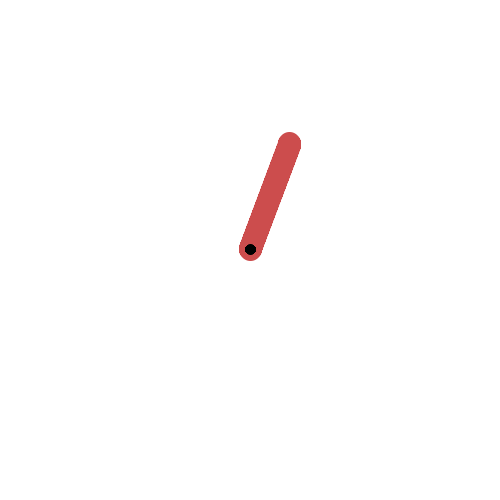

In [ ]:
# Simple deterministic eval + optional GIF for best rollout

best_eval_episode = 170
pendulum_eval_seed = SEED + 10000 + best_eval_episode
n_eval_episodes = 5
make_gif = True

eval_returns = []
best_seed = None
best_return = -np.inf

for ep in range(n_eval_episodes):
    seed = pendulum_eval_seed + ep
    env = gym.make(PENDULUM_ENV_ID)

    obs, _ = env.reset(seed=seed)
    done = False
    total_return = 0.0

    while not done:
        action = pendulum_solver.sample_action(obs, deterministic=True, clip=True)
        step_result = env.step(action)

        if len(step_result) == 5:
            obs, reward, terminated, truncated, _ = step_result
            done = terminated or truncated
        else:
            obs, reward, done, _ = step_result

        total_return += float(reward)

    env.close()
    eval_returns.append(total_return)

    if total_return > best_return:
        best_return = total_return
        best_seed = seed

eval_returns = np.asarray(eval_returns, dtype=float)

print(f"eval_seed_start = {pendulum_eval_seed}")
print(f"returns         = {np.round(eval_returns, 3)}")
print(f"mean_return     = {eval_returns.mean():.3f}")
print(f"std_return      = {eval_returns.std(ddof=0):.3f}")
print(f"var_return      = {eval_returns.var(ddof=0):.3f}")
print(f"min_return      = {eval_returns.min():.3f}")
print(f"max_return      = {eval_returns.max():.3f}")
print(f"best_seed       = {best_seed}")
print(f"best_return     = {best_return:.3f}")

if make_gif:
    import imageio.v2 as imageio
    from IPython.display import Image, display

    gif_path = f"pendulum_best_seed_{best_seed}.gif"
    frames = []

    env = gym.make(PENDULUM_ENV_ID, render_mode="rgb_array")
    obs, _ = env.reset(seed=best_seed)
    done = False

    while not done:
        frames.append(env.render())

        action = pendulum_solver.sample_action(obs, deterministic=True, clip=True)
        step_result = env.step(action)

        if len(step_result) == 5:
            obs, reward, terminated, truncated, _ = step_result
            done = terminated or truncated
        else:
            obs, reward, done, _ = step_result

    env.close()

    imageio.mimsave(gif_path, frames, fps=30)
    display(Image(filename=gif_path))

### Resumable 576-run grid search

The reduced Pendulum ContinuousSBEED grid is implemented as a resumable script so it can be stopped and continued from the CSV.

It keeps this notebook's `Pendulum-v1`, `SEED = 42`, and the same V/rho/policy architectures. The main ranking metric is `avg_reward`; periodic evaluation runs every 10 training episodes and saves `best_eval_*`, while the final simulation saves `final_eval_*`/`eval_*`. Loss summaries are saved as final and tail objective/primal/dual/gradient columns. Re-running the command skips experiment ids already present in the CSV.


In [2]:
# Pendulum ContinuousSBEED grid-search results browser
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    root = PROJECT_ROOT
except NameError:
    def _find_root(current_path):
        current_path = Path(current_path).resolve()
        for parent in [current_path] + list(current_path.parents):
            if (parent / "src" / "rl_methods").exists() and (parent / "data").exists():
                return parent
        return current_path
    root = _find_root(Path.cwd())

RESULTS_PATH = root / "data" / "results" / "sbeed" / "continuous_pendulum_grid.csv"
TOP_N = 20
RANK_METRIC = "best_eval_return_mean"  # Best periodic eval during training; higher is better for Pendulum.

if not RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"Grid-search CSV not found: {RESULTS_PATH}\n"
        "Run experiments/sbeed/scripts/grid_search_continuous_sbeed_pendulum.py first."
    )

raw_results = pd.read_csv(RESULTS_PATH)
results = raw_results.copy()

numeric_cols = [
    "experiment_id", "seconds", "episodes", "env_steps", "optimization_updates",
    "initial_random_steps", "collect_per_episode", "updates_per_episode", "max_buffer_size",
    "hidden_size", "rff_features", "nu", "init_log_std", "gamma", "learning_rate",
    "lr_value", "lr_rho", "lr_policy", "eta", "lambda_entropy", "rollout_length",
    "batch_size", "tau", "fisher_damping", "cg_iters", "buffer_size",
    "train_return_count", "train_return_mean", "train_return_recent_10_mean", "avg_reward",
    "best_eval_episode", "best_eval_update_index", "best_eval_avg_reward",
    "best_eval_return_mean", "best_eval_return_std", "best_eval_return_min",
    "best_eval_return_max", "best_eval_return_median", "best_eval_length_mean",
    "final_eval_avg_reward", "final_eval_return_mean", "final_eval_return_std",
    "final_eval_return_min", "final_eval_return_max", "final_eval_return_median",
    "final_eval_length_mean", "eval_return_mean", "eval_return_std", "eval_return_min",
    "eval_return_max", "eval_return_median", "eval_length_mean", "last_objective",
    "last_primal_mse", "last_dual_mse", "last_theta_grad_norm", "last_beta_grad_norm",
    "last_policy_grad_norm", "last_policy_direction_norm", "tail_objective_mean",
    "tail_objective_std", "tail_primal_mse_mean", "tail_primal_mse_std",
    "tail_dual_mse_mean", "tail_dual_mse_std", "tail_theta_grad_norm_mean",
    "tail_theta_grad_norm_std", "tail_beta_grad_norm_mean", "tail_beta_grad_norm_std",
    "tail_policy_grad_norm_mean", "tail_policy_grad_norm_std",
]
for col in numeric_cols:
    if col in results.columns:
        results[col] = pd.to_numeric(results[col], errors="coerce")

ok = results[results.get("status", "ok").eq("ok")].copy()
failed = results[~results.index.isin(ok.index)].copy()
if RANK_METRIC not in ok.columns or ok[RANK_METRIC].notna().sum() == 0:
    RANK_METRIC = "avg_reward"

ok = ok.sort_values(RANK_METRIC, ascending=False).reset_index(drop=True)
ok["rank"] = np.arange(1, len(ok) + 1)
best = ok.iloc[0]

config_cols = [
    "experiment_id", "rank", "episodes", "learning_rate", "eta", "lambda_entropy",
    "rollout_length", "batch_size", "scheduler_name", "tau", "hidden_size",
    "rff_features", "init_log_std", "gamma", "device", "seconds",
]
metric_cols = [
    "best_eval_return_mean", "best_eval_return_std", "best_eval_episode",
    "final_eval_return_mean", "final_eval_return_std", "avg_reward",
    "train_return_mean", "train_return_recent_10_mean", "last_objective",
    "last_primal_mse", "last_dual_mse", "tail_objective_mean",
    "tail_policy_grad_norm_mean",
]
available_config_cols = [c for c in config_cols if c in ok.columns]
available_metric_cols = [c for c in metric_cols if c in ok.columns]

print(f"Loaded {len(results)} rows from {RESULTS_PATH}")
print(f"Successful runs: {len(ok)} | Failed runs: {len(failed)} | Ranking metric: {RANK_METRIC}")
print(f"Best experiment_id: {int(best['experiment_id'])} | {RANK_METRIC}: {best[RANK_METRIC]:.3f}")

print("\nBest configuration")
display(best[available_config_cols + available_metric_cols].to_frame("value"))

print(f"\nTop {min(TOP_N, len(ok))} runs")
top_runs = ok.loc[: TOP_N - 1, available_config_cols + available_metric_cols]
display(top_runs.style.format(precision=4, na_rep=""))

Loaded 576 rows from /shared/home/mauro.diaz/work/FOGAS/data/results/sbeed/continuous_pendulum_grid.csv
Successful runs: 544 | Failed runs: 32 | Ranking metric: best_eval_return_mean
Best experiment_id: 10 | best_eval_return_mean: -221.721

Best configuration


,value
experiment_id,10
rank,1
episodes,220
learning_rate,0.001
eta,0.004
lambda_entropy,0.001
rollout_length,20
batch_size,20000
scheduler_name,inverse_time_tau_5000
tau,5000.0



Top 20 runs


,experiment_id,rank,episodes,learning_rate,eta,lambda_entropy,rollout_length,batch_size,scheduler_name,tau,hidden_size,rff_features,init_log_std,gamma,device,seconds,best_eval_return_mean,best_eval_return_std,best_eval_episode,final_eval_return_mean,final_eval_return_std,avg_reward,train_return_mean,train_return_recent_10_mean,last_objective,last_primal_mse,last_dual_mse,tail_objective_mean,tail_policy_grad_norm_mean
0,10,1,220,0.0010,0.0040,0.0010,20,20000,inverse_time_tau_5000,5000.0000,64,100,-1.5000,0.9950,cuda:4,1048.9988,-221.7207,160.2775,170.0000,-1334.7807,157.4852,-1334.7807,-1109.3823,-1358.4882,9223.2998,9243.6475,5086.8706,16812.0662,61934.8238
1,298,2,330,0.0010,0.0040,0.0010,20,20000,inverse_time_tau_5000,5000.0000,64,100,-1.5000,0.9950,cuda:4,2556.6125,-221.7207,160.2775,170.0000,-1269.0577,236.8893,-1269.0577,-1203.4593,-1360.8963,66768.6484,67057.7812,72283.2344,27085.1640,110160.3573
2,285,3,220,0.0001,0.1000,0.1000,20,10000,inverse_time_tau_20000,20000.0000,64,100,-1.5000,0.9950,cuda:3,864.6983,-689.4420,140.8610,10.0000,-1533.2904,75.4099,-1533.2904,-1342.7921,-1522.7073,2941.7012,3301.6106,3599.0938,3136.6292,24066.3690
3,573,4,330,0.0001,0.1000,0.1000,20,10000,inverse_time_tau_20000,20000.0000,64,100,-1.5000,0.9950,cuda:3,1551.8962,-689.4420,140.8610,10.0000,-1478.2708,159.7300,-1478.2708,-1370.1074,-1416.2453,2800.7881,3149.9932,3492.0518,2921.1471,23785.7004
4,572,5,330,0.0001,0.1000,0.1000,20,10000,inverse_time_tau_5000,5000.0000,64,100,-1.5000,0.9950,cuda:2,1538.2716,-729.6780,56.1315,10.0000,-1298.9087,262.8450,-1298.9087,-1275.0817,-1395.7822,164.5247,189.7118,251.8709,165.5147,118.5281
5,284,6,220,0.0001,0.1000,0.1000,20,10000,inverse_time_tau_5000,5000.0000,64,100,-1.5000,0.9950,cuda:2,857.0815,-729.6780,56.1315,10.0000,-1252.9299,266.8854,-1252.9299,-1244.5635,-1401.9140,369.1843,406.3917,372.0741,361.8837,4409.3440
6,31,7,220,0.0010,0.0040,0.1000,10,20000,inverse_time_tau_20000,20000.0000,64,100,-1.5000,0.9950,cuda:1,663.2210,-747.8427,323.2551,70.0000,-1594.9585,85.4027,-1594.9585,-1386.9716,-1488.4960,4116.4751,4122.5083,1508.2573,7792.3424,22743.9160
7,319,8,330,0.0010,0.0040,0.1000,10,20000,inverse_time_tau_20000,20000.0000,64,100,-1.5000,0.9950,cuda:1,1123.4253,-747.8427,323.2551,70.0000,-1129.2132,59.1466,-1129.2132,-1384.3268,-1148.4800,1054.3646,1055.0122,161.9101,10501.8178,42193.2246
8,236,9,220,0.0001,0.0400,0.0100,20,10000,inverse_time_tau_5000,5000.0000,64,100,-1.5000,0.9950,cuda:2,853.5417,-778.3458,59.2410,190.0000,-750.3841,3.9672,-750.3841,-1169.3169,-1135.0149,3249.2549,3284.2571,875.0571,3319.1085,7495.8638
9,524,10,330,0.0001,0.0400,0.0100,20,10000,inverse_time_tau_5000,5000.0000,64,100,-1.5000,0.9950,cuda:2,1543.2853,-778.3458,59.2410,190.0000,-955.1200,230.9050,-955.1200,-1159.7295,-1212.8863,1619.8910,1639.0277,478.4184,1631.3587,3026.1102
